**Project 1 - Animation: https://colab.research.google.com/drive/1GWWCogGfYmt3e-QhnhJirV6BIrZcgcf-?usp=sharing**

# Final Project Option 2: Developing the thermal evolution model

Here you will work with the thermal evolution model of Earth's mantle we developed for Exercise 8 and in the lecture notebook for that day. You will add some further effects and calculations to the model, which are [based in this paper if you want to see the full source](https://drive.google.com/file/d/1b68U4ALGbxh3sVy1WeuvwieFrK2VkLJr/view?usp=sharing). As a reminder, here are the equations:

$\frac{dT}{dt} = \frac{H}{c_p} - \frac{A F_s}{M c_p}$

where $M$ is the mass of the mantle, $c_p$ is the specific heat of the mantle, $T$ is the mantle temperature, $t$ is time, $H$ is the total heat production rate per unit mass from radioactive elements, $A$ is the surface area of the Earth, and $F_s$ is the heat flux out of the mantle.

The heat flux, $F_s$, is given by:

$F_s = ck \frac{(T-T_s)^{4/3}}{d} \left( \frac{\rho g \alpha d^3}{\kappa \mu} \right)^{1/3}$

where $c$ is a constant, $k$ is the thermal conductivity of the Earth, $T_s$ is the surface temperature, $d$ is the thickness of the mantle, $\rho$ is the average density of the mantle, $g$ is acceleration due to gravity, $\alpha$ is the thermal expansion coefficient, $\kappa$ is the thermal diffusivity, and $\mu$ is the viscosity. I gave numbers for these parameters in the lecture notebook; use the same numbers unless otherwise stated for the following questions.

The heat production rate decays over time following the equation:

$H = H_0 \exp{\left(- \frac{t}{\tau} \right)} $

where $H_0$ is the heat production rate at time $t=0$, which corresponds to the time of Earth's formation and $\tau$ is a decay constant.

The viscosity depends on mantle temperature, $T$, following the equation:

$\mu = \mu_{ref} \exp{\left(\frac{E_v}{R} \left(\frac{1}{T}-\frac{1}{T_{ref}} \right) \right)}$

where $\mu_{ref} = 10^{21}$ Pa s (Pascal seconds) is the refernece viscosity, defined as the present day mantle viscosity. $E_v = 350000$ J/mol is the activation energy, $R=8.314$ is the gas constant, $T_{ref} = 1623$ K.

Here's all the other parameter values:

In [1]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
c=0.12
k=5 # units are W/m/K
d=2890000 # thicknesss of the mantle in m
Ts=273 # Surface temperature in degrees kelvin
rho=4500 # average density of the mantle in kg/m^3
g=9.8 # acceleration from gravity in m/s^2
alpha=3e-5 # thermal expansion coefficient in units of 1/K
kappa=1e-6 # thermal diffusion coefficient in m^2/s
mu=1e21 # Viscosity of the mantle in Pa s (Pascal seconds)

M=4.04e24 # mass of the mantle in kilograms
A=4*np.pi*6371000**2 # surface area of Earth in meters
cp=1250 # specific heat, units are J kg^-1 K^-1

tau=2.94e9*3600*24*365

mu_ref=1e21 # Viscosity of the mantle at present day, Pa s
Ev=350000 # Activation energy in J/mol
R=8.314 # Universal gas consant
T_ref=1350+273 # Reference mantle temperature

**Part 1.** First, run the model like you did for the last question in exercise 8. But in addition to plotting temperature, I also want you to make a second plot showing $MH$ and $F_sA$ over time. Both should have units of Terrawatts. This figure will show the competition between heat production and heat loss; when heat production is larger mantle temperature will be increasing, and when heat loss is larger mantle temperature will be decreasing.  

To make this plot, you will need to calculate $H(t)$ and $F_s(t)$ based on the solution for mantle temperature and corresponding time you get from solving the differential equation.

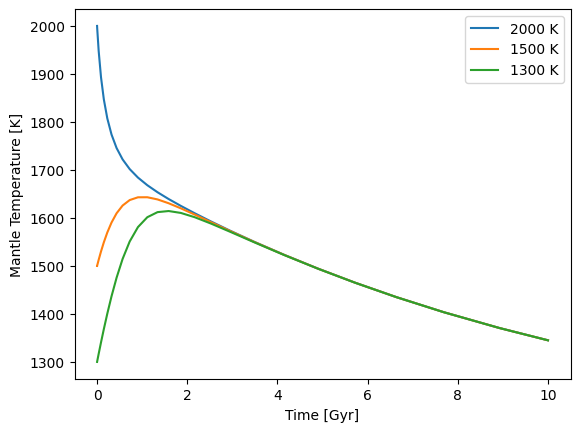

In [3]:
Ev = 3.5*10**5
H0 = 2*10**(-11)
decay = (2.9e9)*3600*24*365

def temp(t,T):
  Fs=c*k*(T-Ts)**(4/3)*(1/d)*((rho*g*alpha*d**3)/(kappa*(mu_ref*np.exp((Ev/R)*((1/T)-(1/T_ref))))))**(1/3)
  return ((H0*np.exp(-t/decay))/cp - A*Fs/(M*cp))

t_span = np.array([0,10e9*3600*24*365])
T0 = np.array([2000, 1500, 1300])

sol = sp.integrate.solve_ivp(temp, t_span, T0, atol=1e-6, rtol=1e-6)
t_sol = sol.t
T_sol = sol.y

plt.plot(t_sol/(1e9*3600*24*365),T_sol[0], t_sol/(1e9*3600*24*365),T_sol[1], t_sol/(1e9*3600*24*365),T_sol[2])
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature [K]")
plt.legend(["2000 K","1500 K","1300 K"])

plt.show()

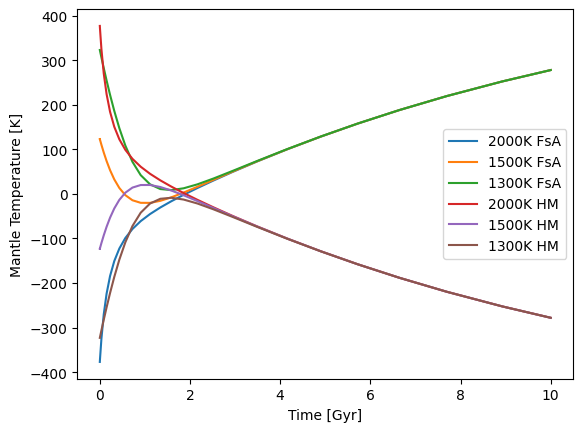

In [4]:
Temp = np.array(T_sol).astype(float)
# H0*np.exp(-t/decay)*M

FsA_2000 = T_ref - Temp[0]
FsA_1500 = T_ref - Temp[1]
FsA_1300 = T_ref - Temp[2]

HM_2000 = Temp[0] - T_ref
HM_1500 = Temp[1] - T_ref
HM_1300 = Temp[2] - T_ref

plt.plot(t_sol/(1e9*3600*24*365),FsA_2000, t_sol/(1e9*3600*24*365),FsA_1500, t_sol/(1e9*3600*24*365),FsA_1300)
plt.plot(t_sol/(1e9*3600*24*365),HM_2000, t_sol/(1e9*3600*24*365),HM_1500, t_sol/(1e9*3600*24*365),HM_1300)
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature [K]")
plt.legend(["2000K FsA","1500K FsA","1300K FsA", "2000K HM","1500K HM","1300K HM"])

plt.show()

**Part 2.** Make the same plots as part 1 but very the initial heat production rate, $H_0$, over the range $5 \times 10^{-10}$ W/kg to $5 \times 10^{-11}$ W/kg. You can use the same initial mantle temperature fall all models, $T_0 = 1800$ K.



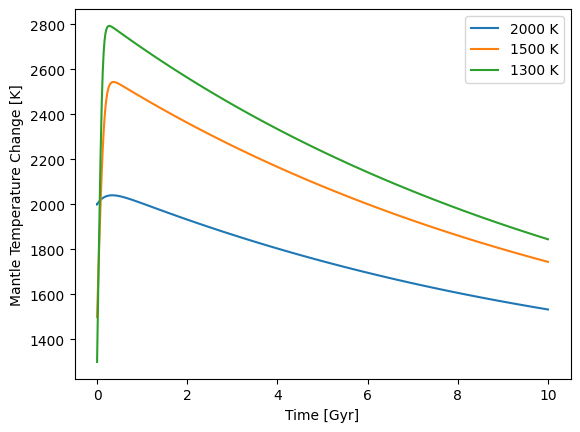

In [5]:
Ev = 3.5*10**5
H_0_value = np.linspace(5*10**(-11), 5*10**(-10), 3)
decay = (2.9e9)*3600*24*365
T_ref = 1800

def heat(t,T, H_0):
  Fs = c*k*((T-Ts))**(4/3)*(1/d)*((rho*g*alpha*d**3)/(kappa*(mu_ref*np.exp((Ev/R)*((1/T)-(1/T_ref))))))**(1/3)
  return ((H_0*np.exp(-t/decay))/cp - A*Fs/(M*cp))

t_span = np.array([0,10e9*3600*24*365])
T0 = np.array([2000, 1500, 1300])

sol = sp.integrate.solve_ivp(heat, t_span, T0, atol=1e-6, rtol=1e-6, args=(H_0_value,))
t_sol = sol.t
T_sol = sol.y

plt.plot(t_sol/(1e9*3600*24*365),T_sol[0], t_sol/(1e9*3600*24*365),T_sol[1], t_sol/(1e9*3600*24*365),T_sol[2])
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature Change [K]")
plt.legend(["2000 K","1500 K","1300 K"])

**Part 3.** Now we will make some significant modifications to the code to look at more complicated situations. First we will look at the evolution for a case called "stagnant-lid tectonics." On Earth we have plate tectonics with a network of mobile plates. But other planets, like Mars, have stagnant-lid tectonics, where the whole surface is frozen and immobile.

This style of tectonics changes the surface heat flux to a different formula:

$F_s = ck \frac{(T-T_s)}{d} \left( \frac{\rho g \alpha (T-T_s) d^3}{\kappa \mu} \right)^{1/3} \left(\frac{E_v(T-T_s)}{RT^2} \right)^{-4/3}$

In this case $c=0.5$.

Modify the code to change the heat flux to the above formula for stagnant-lid convection. Model and plot thermal evolution for varying starting temperatures betwee 1500 and 2000 K and for initial heat production rates ranging from $5 \times 10^{10}$ W/kg to $5 \times 10^{11}$ W/kg.

Compare and contrast your results with stagnant-lid tectonics to your results with the previous heat flux equation, which corresponds to plate tectonics.

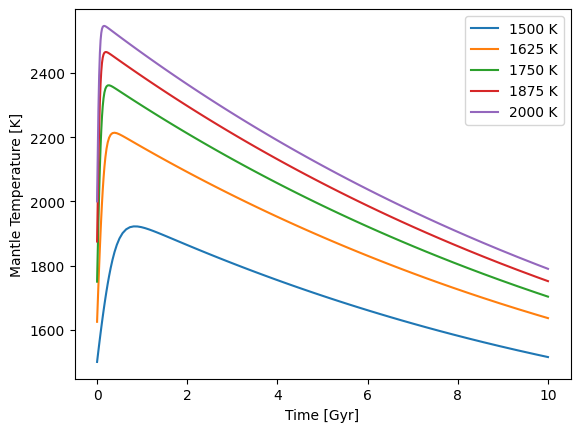

In [6]:
c = 0.5
H_0_value = np.linspace(5*10**(-11), 5*10**(-10), 5)    #5*10**(-1X) or 5*10**(1X)
T_ref = 1800

def flux(t,T,H_0):
  Fs=c*k*((T-Ts)**(4/3))*(1/d)*(((rho*g*alpha*d**3)/(kappa*(mu_ref*np.exp((Ev/R)*((1/T)-(1/T_ref))))))**(1/3))*((Ev*(T-Ts))/((R*T)**2))**(-4/3)
  return ((H_0*np.exp(-t/decay))/cp - A*Fs/(M*cp))

t_span = np.array([0,10e9*3600*24*365])
T0 = np.linspace(1500, 2000, 5)

sol = sp.integrate.solve_ivp(flux, t_span, T0, atol=1e-6, rtol=1e-6, args=(H_0_value,))
t_sol = sol.t
T_sol = sol.y

plt.plot(t_sol/(1e9*3600*24*365),T_sol[0], t_sol/(1e9*3600*24*365),T_sol[1], t_sol/(1e9*3600*24*365),T_sol[2], t_sol/(1e9*3600*24*365),T_sol[3], t_sol/(1e9*3600*24*365),T_sol[4])
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature [K]")
plt.legend(["1500 K", "1625 K", "1750 K", "1875 K", "2000 K"])

plt.show()

**Part 4.** Plot heat production, $MH$, and heat loss $AF_s$, for the models you ran in Part 3. Compare and contrast this result to your answers from part 1.

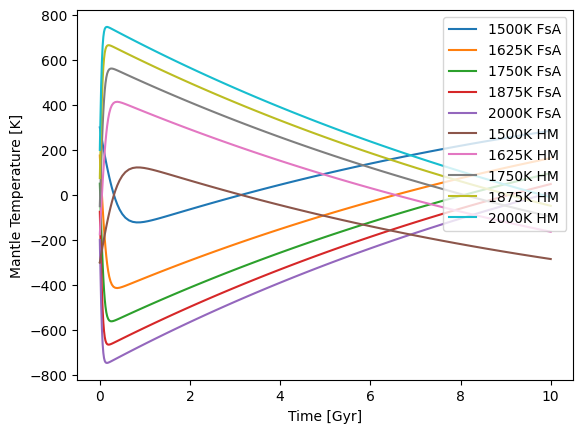

In [7]:
Temp2 = np.array(T_sol).astype(float)

FsA_1500 = T_ref - Temp2[0]
FsA_1625 = T_ref - Temp2[1]
FsA_1750 = T_ref - Temp2[2]
FsA_1875 = T_ref - Temp2[3]
FsA_2000 = T_ref - Temp2[4]

HM_1500 = Temp2[0] - T_ref
HM_1625 = Temp2[1] - T_ref
HM_1750 = Temp2[2] - T_ref
HM_1875 = Temp2[3] - T_ref
HM_2000 = Temp2[4] - T_ref

plt.plot(t_sol/(1e9*3600*24*365),FsA_1500, t_sol/(1e9*3600*24*365),FsA_1625, t_sol/(1e9*3600*24*365),FsA_1750, t_sol/(1e9*3600*24*365),FsA_1875, t_sol/(1e9*3600*24*365),FsA_2000)
plt.plot(t_sol/(1e9*3600*24*365),HM_1500, t_sol/(1e9*3600*24*365),HM_1625, t_sol/(1e9*3600*24*365),HM_1750, t_sol/(1e9*3600*24*365),HM_1875, t_sol/(1e9*3600*24*365),HM_2000)
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature [K]")
plt.legend(["1500K FsA","1625K FsA","1750K FsA","1875K FsA","2000K FsA", "1500K HM","1625K HM","1750K HM","1875K HM","2000K HM"])

plt.show()

**Part 5.** Now you will calculate and plot the rate of melt production from the thermal evolution models you ran in Part 3. Melt production is calculated from the following set of equations. First, we need to calculate the pressure where the first starts to melt, $P_i$:

$P_i = \frac{T-1423}{120 \times 10^{-9} - 10^{-8}}$

where pressure is in units of Pascals and temperature in units of Kelvin. The hotter the mantle the deeper melting begins, because melting temperature for mantle rocks increases with increasing presssure/depth.

Melting stops at the pressure:

$P_f = \rho g \delta$

where $\delta$ is the thickness of the lithosphere (the rigid outer part of the planet), which follows the equation:

$\delta = \frac{k (T-T_s)}{F_s}$. $\delta$ should have units of meters ot be consistent with the other equations.

The rate of melt production, $f_m$, in units of m$^3$/s is:

$f_m = 17.8 \pi R_p v (d_m-\delta) \phi$

where $R_p = 6371000$ m is the radius of the planet, $v$ is the average velocity of convection in the mantle, $d_m = P_i/(\rho g)$ is the depth where melting in the mantle starts, and the average melt fraction, $\phi$, is

$\phi = \frac{P_i - P_f}{2} \left(\frac{d \phi}{dP} \right)_S$

and $\left(\frac{d \phi}{dP} \right)_S = 1.5 \times 10^{-10}$ 1/Pa.

That's a lot of equations to include, but is everything you need to calculate $f_m$ as a function of time for the models you ran in part 3.



In [8]:
Rp = 6371000
d0Ps = 1.5*10**(-10)

Tsol = np.array(T_sol).astype(float)
tsol = np.array(t_sol).astype(float)

av_v1 = []
for i in range(1,len(tsol)):
  av_v1.append(Tsol[0][i]/tsol[i])
av_v_1500 = np.average(av_v1)

av_v2 = []
for i in range(1,len(tsol)):
  av_v2.append(Tsol[1][i]/tsol[i])
av_v_1625 = np.average(av_v2)

av_v3 = []
for i in range(1,len(tsol)):
  av_v3.append(Tsol[2][i]/tsol[i])
av_v_1750 = np.average(av_v3)

av_v4 = []
for i in range(1,len(tsol)):
  av_v4.append(Tsol[3][i]/tsol[i])
av_v_1875 = np.average(av_v4)

av_v5 = []
for i in range(1,len(tsol)):
  av_v5.append(Tsol[4][i]/tsol[i])
av_v_2000 = np.average(av_v5)

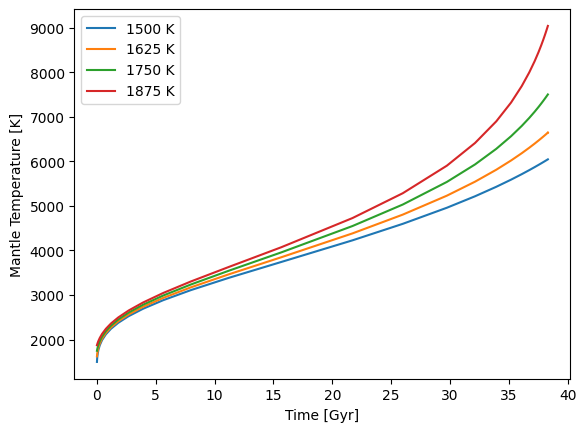

In [9]:
v_value = v_value = np.array([av_v_1500, av_v_1625, av_v_1750, av_v_1875, av_v_2000])

def melt(t,T,v):
  Fs=c*k*((T-Ts)**(4/3))*(1/d)*(((rho*g*alpha*d**3)/(kappa*(mu_ref*np.exp((Ev/R)*((1/T)-(1/T_ref))))))**(1/3))*(Ev*(T-Ts)/R*T**2)**(-4/3)
  Pi = (T-1423)/((120*10**(-9))-10**(-8))
  delta = k*(T-Ts)/Fs
  return 17.8*np.pi*Rp*v*((Pi/(rho*g))-delta)*(1/2)*(Pi-(rho*g*delta))*d0Ps

t_span = np.array([0, 10e9*3600*24*365])
T0 = np.linspace(1500, 2000, 5)

sol = sp.integrate.solve_ivp(melt, t_span, T0, atol=1e-6, rtol=1e-6, args=(v_value,))
t_sol = sol.t
T_sol = sol.y

plt.plot(t_sol/(1e-59*3600*9.6*365),T_sol[0], t_sol/(1e-59*3600*9.6*365),T_sol[1], t_sol/(1e-59*3600*9.6*365),T_sol[2], t_sol/(1e-59*3600*9.6*365),T_sol[3])
plt.xlabel("Time [Gyr]")
plt.ylabel("Mantle Temperature [K]")
plt.legend(["1500 K", "1625 K", "1750 K", "1875 K", "2000 K"])

plt.show()